# 02 - Mô hình Machine Learning với scikit-learn

Nội dung: baseline -> tinh chỉnh siêu tham số -> phân tích đặc trưng quan trọng -> ensemble -> chọn mô hình **theo kết quả cross-validation** -> xuất file nộp Kaggle.

Tất cả mô hình dùng **cùng một bộ chia 5-fold (seed 42)** để so sánh công bằng (và cùng bộ chia với notebook 03).

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
warnings.filterwarnings("ignore")

# 'clean' = bộ đặc trưng tạo ở notebook 01
# 'best'  = bộ đặc trưng tốt nhất tìm được ở notebook 04 (chạy 04 trước rồi đổi giá trị này)
FEATURE_SET = "clean"

X_train = pd.read_csv(f"../data/X_train_{FEATURE_SET}.csv")
X_test = pd.read_csv(f"../data/X_test_{FEATURE_SET}.csv")
y_train = pd.read_csv("../data/y_train_clean.csv")["SalePrice"]
sample_submission = pd.read_csv("../data/sample_submission.csv")

os.makedirs("../results", exist_ok=True)
os.makedirs("../submissions", exist_ok=True)

print("Bộ đặc trưng:", FEATURE_SET)
print("X_train:", X_train.shape, "| X_test:", X_test.shape, "| y_train:", y_train.shape)

Bộ đặc trưng: clean
X_train: (1458, 306) | X_test: (1459, 306) | y_train: (1458,)


In [2]:
SEED = 42
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)   # dùng chung cho mọi mô hình

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))

def rmse_cv(model):
    # RMSE của từng fold (trên log giá) - đúng metric của cuộc thi
    return -cross_val_score(model, X_train, y_train, cv=kf,
                            scoring="neg_root_mean_squared_error", n_jobs=-1)

## 1. Baseline
Linear model cần chuẩn hóa -> dùng `RobustScaler` (ít bị ảnh hưởng bởi các cột One-Hot hiếm).

In [3]:
baselines = {
    "Ridge (không scale, alpha=10)":      Ridge(alpha=10.0),
    "Ridge (RobustScaler, alpha=10)":     make_pipeline(RobustScaler(), Ridge(alpha=10.0)),
    "Lasso (RobustScaler, alpha=0.001)":  make_pipeline(RobustScaler(), Lasso(alpha=0.001, max_iter=50000)),
    "ElasticNet (RobustScaler)":          make_pipeline(RobustScaler(), ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=50000)),
    "Random Forest":                      RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1),
    "Gradient Boosting":                  GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=SEED),
}

baseline_rows = []
for name, model in baselines.items():
    s = rmse_cv(model)
    baseline_rows.append({"Mô hình": name, "CV RMSE": s.mean(), "Std": s.std()})
    print(f"{name:38s} CV RMSE: {s.mean():.4f} (+/- {s.std():.4f})")

baseline_df = pd.DataFrame(baseline_rows)

Ridge (không scale, alpha=10)          CV RMSE: 0.1124 (+/- 0.0083)
Ridge (RobustScaler, alpha=10)         CV RMSE: 0.1114 (+/- 0.0082)
Lasso (RobustScaler, alpha=0.001)      CV RMSE: 0.1114 (+/- 0.0079)
ElasticNet (RobustScaler)              CV RMSE: 0.1097 (+/- 0.0076)
Random Forest                          CV RMSE: 0.1363 (+/- 0.0062)
Gradient Boosting                      CV RMSE: 0.1278 (+/- 0.0059)


## 2. Tinh chỉnh siêu tham số
GridSearch cho mô hình tuyến tính, RandomizedSearch cho Gradient Boosting (có thể mất vài phút).

In [4]:
def clean_params(p):
    return {k: (round(float(v), 6) if isinstance(v, (np.floating, float)) else v) for k, v in p.items()}

def run_search(search, name):
    search.fit(X_train, y_train)
    i = search.best_index_
    mean = -search.cv_results_["mean_test_score"][i]
    std = search.cv_results_["std_test_score"][i]
    print(f"{name:12s} CV RMSE: {mean:.4f} (+/- {std:.4f}) | tham số tốt nhất: {clean_params(search.best_params_)}")
    return search, mean, std

scoring = "neg_root_mean_squared_error"
tuned = {}

ridge_gs = GridSearchCV(make_pipeline(RobustScaler(), Ridge()),
                        {"ridge__alpha": np.logspace(-1, 2.5, 15)}, cv=kf, scoring=scoring, n_jobs=-1)
tuned["Ridge"] = run_search(ridge_gs, "Ridge")

lasso_gs = GridSearchCV(make_pipeline(RobustScaler(), Lasso(max_iter=50000)),
                        {"lasso__alpha": np.logspace(-4, -1.5, 12)}, cv=kf, scoring=scoring, n_jobs=-1)
tuned["Lasso"] = run_search(lasso_gs, "Lasso")

enet_gs = GridSearchCV(make_pipeline(RobustScaler(), ElasticNet(max_iter=50000)),
                       {"elasticnet__alpha": np.logspace(-4, -1.5, 8), "elasticnet__l1_ratio": [0.1, 0.5, 0.9]},
                       cv=kf, scoring=scoring, n_jobs=-1)
tuned["ElasticNet"] = run_search(enet_gs, "ElasticNet")

Ridge        CV RMSE: 0.1113 (+/- 0.0082) | tham số tốt nhất: {'ridge__alpha': 17.782794}
Lasso        CV RMSE: 0.1095 (+/- 0.0074) | tham số tốt nhất: {'lasso__alpha': 0.000481}
ElasticNet   CV RMSE: 0.1096 (+/- 0.0074) | tham số tốt nhất: {'elasticnet__alpha': 0.000518, 'elasticnet__l1_ratio': 0.9}


In [5]:
gbr_params = {
    "n_estimators": [300, 500, 800],
    "learning_rate": [0.02, 0.03, 0.05],
    "max_depth": [2, 3, 4],
    "min_samples_leaf": [5, 10, 15],
    "max_features": ["sqrt", 0.3, 0.5],
    "subsample": [0.6, 0.8, 1.0],
}
gbr_rs = RandomizedSearchCV(GradientBoostingRegressor(random_state=SEED), gbr_params, n_iter=15,
                            cv=kf, scoring=scoring, n_jobs=-1, random_state=SEED)
tuned["GBR"] = run_search(gbr_rs, "GBR")

GBR          CV RMSE: 0.1155 (+/- 0.0070) | tham số tốt nhất: {'subsample': 0.8, 'n_estimators': 500, 'min_samples_leaf': 5, 'max_features': 0.3, 'max_depth': 3, 'learning_rate': 0.03}


## 3. Đặc trưng quan trọng
Dùng để hiểu mô hình và để chọn/bỏ đặc trưng (thực nghiệm chi tiết ở notebook 04).

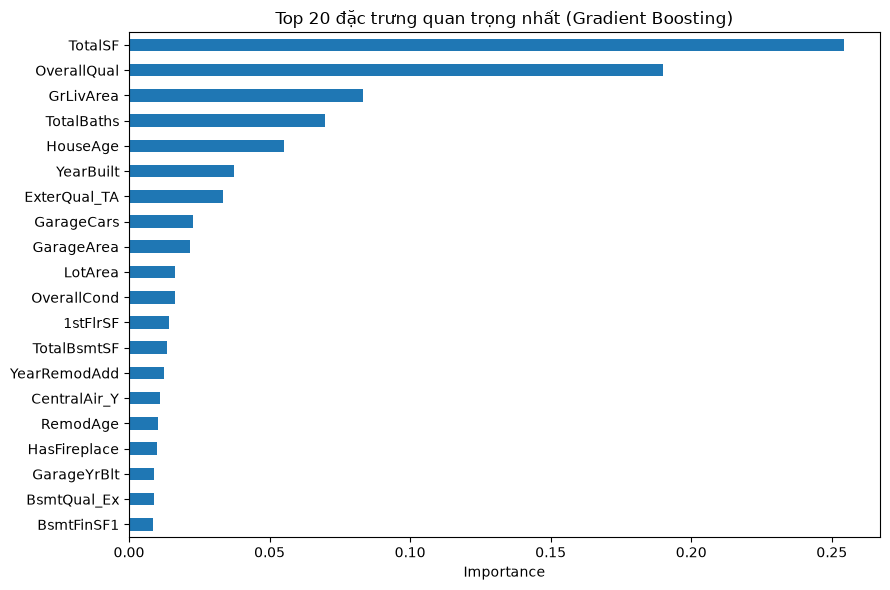

Lasso giữ lại 112 / 306 đặc trưng (hệ số khác 0)
Top 10 hệ số lớn nhất (giá trị tuyệt đối):
MSZoning_C (all)       -0.2844
GrLivArea               0.1164
Neighborhood_Crawfor    0.1024
OverallQual             0.0968
Neighborhood_StoneBr    0.0869
HouseAge               -0.0736
Functional_Typ          0.0733
TotalSF                 0.0707
KitchenQual_Ex          0.0651
Exterior1st_BrkFace     0.0637
dtype: float64


In [6]:
best_gbr = tuned["GBR"][0].best_estimator_
imp = pd.Series(best_gbr.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
imp.head(20)[::-1].plot(kind="barh")
plt.title("Top 20 đặc trưng quan trọng nhất (Gradient Boosting)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

lasso_best = tuned["Lasso"][0].best_estimator_
coef = pd.Series(lasso_best.named_steps["lasso"].coef_, index=X_train.columns)
print(f"Lasso giữ lại {(coef != 0).sum()} / {len(coef)} đặc trưng (hệ số khác 0)")
print("Top 10 hệ số lớn nhất (giá trị tuyệt đối):")
print(coef.reindex(coef.abs().sort_values(ascending=False).index).head(10).round(4))

## 4. Ensemble & chọn mô hình
Dự đoán out-of-fold (OOF) của các mô hình tốt nhất (cùng bộ fold) được dùng để thử kết hợp:
`pred = (1 - w) * mean(Ridge, Lasso, ElasticNet) + w * GBR`, chọn `w` trên lưới thô 0..1 (bước 0.1).

*Lưu ý:* siêu tham số và `w` được chọn trên cùng cross-validation nên điểm CV có thể hơi lạc quan; điểm Kaggle public mới là phép kiểm tra độc lập.

Trọng số GBR tốt nhất: w = 0.3  (OOF RMSE = 0.1084)


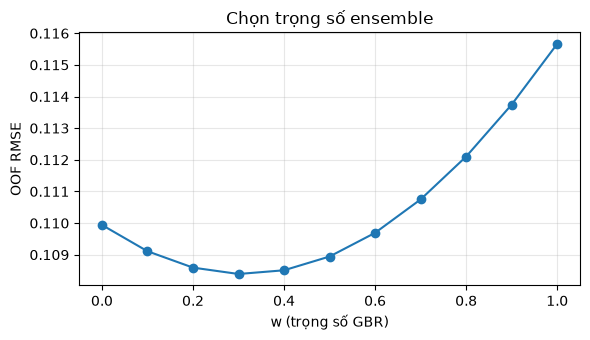

In [7]:
best_models = {name: tuned[name][0].best_estimator_ for name in ["Ridge", "Lasso", "ElasticNet", "GBR"]}

oof = {name: cross_val_predict(m, X_train, y_train, cv=kf, n_jobs=-1) for name, m in best_models.items()}

lin_oof = np.mean([oof["Ridge"], oof["Lasso"], oof["ElasticNet"]], axis=0)
weights = [round(float(w), 1) for w in np.linspace(0, 1, 11)]
blend_scores = {w: rmse(y_train, (1 - w) * lin_oof + w * oof["GBR"]) for w in weights}
best_w = min(blend_scores, key=blend_scores.get)
oof["Blend"] = (1 - best_w) * lin_oof + best_w * oof["GBR"]
print(f"Trọng số GBR tốt nhất: w = {best_w}  (OOF RMSE = {blend_scores[best_w]:.4f})")

plt.figure(figsize=(6, 3.5))
plt.plot(list(blend_scores.keys()), list(blend_scores.values()), marker="o")
plt.xlabel("w (trọng số GBR)"); plt.ylabel("OOF RMSE"); plt.title("Chọn trọng số ensemble"); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [8]:
rows = []
for name in ["Ridge", "Lasso", "ElasticNet", "GBR"]:
    rows.append({"Mô hình": name, "CV RMSE (mean)": tuned[name][1], "CV RMSE (std)": tuned[name][2],
                 "OOF RMSE": rmse(y_train, oof[name])})
rows.append({"Mô hình": f"Blend (w_GBR={best_w})", "CV RMSE (mean)": np.nan, "CV RMSE (std)": np.nan,
             "OOF RMSE": rmse(y_train, oof["Blend"])})
results_df = pd.DataFrame(rows).sort_values("OOF RMSE").reset_index(drop=True)
results_df.to_csv("../results/sklearn_cv.csv", index=False)
display(results_df.round(4))

final_name = "Blend" if rmse(y_train, oof["Blend"]) <= min(rmse(y_train, oof[n]) for n in best_models) \
             else min(best_models, key=lambda n: rmse(y_train, oof[n]))
print("=> Mô hình được chọn (theo OOF RMSE thấp nhất):", final_name)

,Mô hình,CV RMSE (mean),CV RMSE (std),OOF RMSE
0,Blend (w_GBR=0.3),NaN,NaN,0.1084
1,Lasso,0.1095,0.0074,0.1098
2,ElasticNet,0.1096,0.0074,0.1098
3,Ridge,0.1113,0.0082,0.1116
4,GBR,0.1155,0.0070,0.1157


=> Mô hình được chọn (theo OOF RMSE thấp nhất): Blend


## 5. Huấn luyện lại trên toàn bộ train & xuất file nộp

In [9]:
test_log = {}
for name, m in best_models.items():
    m.fit(X_train, y_train)
    test_log[name] = m.predict(X_test)
test_log["Blend"] = (1 - best_w) * np.mean([test_log["Ridge"], test_log["Lasso"], test_log["ElasticNet"]], axis=0) \
                    + best_w * test_log["GBR"]

final_test_log = test_log[final_name]
final_oof = oof[final_name]

# expm1: đưa log giá về giá thật ($)
submission = pd.DataFrame({"Id": sample_submission["Id"], "SalePrice": np.expm1(final_test_log)})
assert len(submission) == len(sample_submission) and submission["SalePrice"].notna().all() and (submission["SalePrice"] > 0).all()
submission.to_csv("../submissions/submission_sklearn.csv", index=False)

# Lưu dự đoán (thang log) để notebook 03 so sánh / blend
np.save("../results/oof_sklearn.npy", final_oof)
np.save("../results/test_pred_sklearn_log.npy", final_test_log)

print("Đã xuất '../submissions/submission_sklearn.csv'")
print(submission["SalePrice"].describe().round(0))
submission.head()

Đã xuất '../submissions/submission_sklearn.csv'
count      1459.0
mean     178758.0
std       78549.0
min       42888.0
25%      126769.0
50%      157409.0
75%      210108.0
max      824490.0
Name: SalePrice, dtype: float64


,Id,SalePrice
0,1461,120403.831991
1,1462,156079.947048
2,1463,183392.458349
3,1464,195884.458474
4,1465,194210.155641
